In [1]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [2]:
X_train  = np.load("../data/X_train.npy")
X_test   = np.load("../data/X_test.npy")
yr_train = np.load("../data/yr_train.npy")
yr_test  = np.load("../data/yr_test.npy")

print(X_train.shape)
print(X_test.shape)
print(yr_train.shape)
print(yr_test.shape)

(6400, 6)
(1600, 6)
(6400,)
(1600,)


In [3]:
reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

reg.fit(X_train, yr_train)

print("Regressor trained.")

Regressor trained.


In [4]:
yr_pred = reg.predict(X_test)

mae  = mean_absolute_error(yr_test, yr_pred)
rmse = mean_squared_error(yr_test, yr_pred) ** 0.5

print(f"MAE:  {mae:.0f} hours")
print(f"RMSE: {rmse:.0f} hours")
print(f"RMSE as % of range: {rmse/10000*100:.1f}%")

MAE:  258 hours
RMSE: 320 hours
RMSE as % of range: 3.2%


In [5]:
import numpy as np

print("RUL train:")
print("Min:", yr_train.min())
print("Max:", yr_train.max())
print("Mean:", yr_train.mean())

print("\nRUL test:")
print("Min:", yr_test.min())
print("Max:", yr_test.max())
print("Mean:", yr_test.mean())

RUL train:
Min: 233
Max: 10000
Mean: 5545.81390625

RUL test:
Min: 480
Max: 10000
Mean: 5521.1825


In [6]:
import pandas as pd

df = pd.read_csv("../data/ssd_data.csv")

print(df["RUL"].describe())

count     8000.000000
mean      5540.887625
std       2352.476811
min        233.000000
25%       3519.000000
50%       5539.000000
75%       7541.000000
max      10000.000000
Name: RUL, dtype: float64


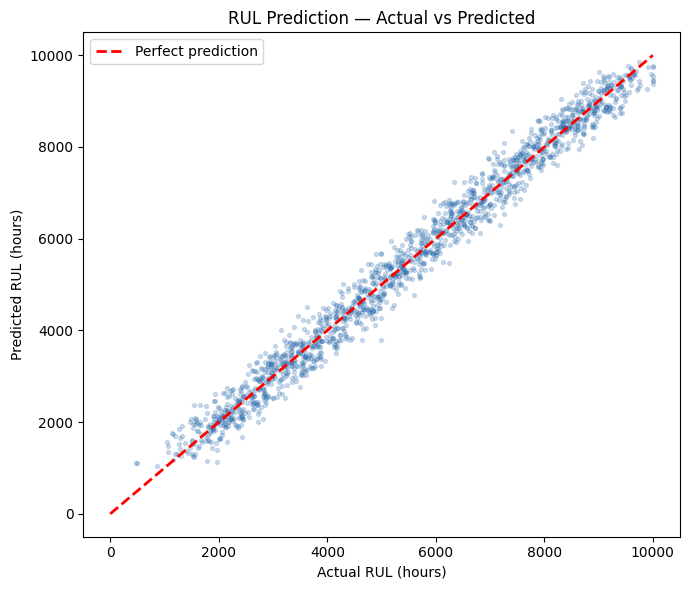

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))
plt.scatter(yr_test, yr_pred, alpha=0.2, s=8, color="#185FA5")
plt.plot([0, 10000], [0, 10000], "r--", lw=2, label="Perfect prediction")
plt.xlabel("Actual RUL (hours)")
plt.ylabel("Predicted RUL (hours)")
plt.title("RUL Prediction — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/rul_actual_vs_predicted.png",
            bbox_inches="tight", dpi=150)
plt.show()

In [8]:
import os
print(os.getcwd())

C:\Users\SKANDHAS\ssd-health-monitor\ssd-health-monitor\notebooks


In [9]:
type(reg)

sklearn.ensemble._forest.RandomForestRegressor

In [11]:
import sklearn
print(sklearn.ensemble.RandomForestRegressor)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [12]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(reg, "../models/regression.pkl")

print("✅ Model saved at ../models/regression.pkl")

✅ Model saved at ../models/regression.pkl


In [ ]:
import os

print(os.path.exists("../models/regression.pkl"))